In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
import pymaster as nmt
import os

Read mask from which to generate catalogs

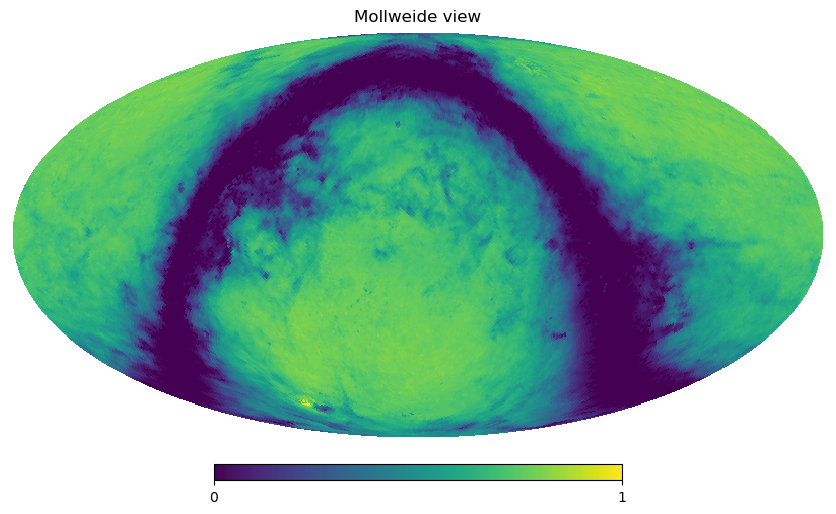

In [2]:
nside = 256
npix = hp.nside2npix(nside)

msk = hp.read_map("/home/damonge/Science/Datasets/GAIA/new_catalog/selection_function_NSIDE64_G20.5.fits")
msk = hp.ud_grade(msk, nside_out=nside)
msk /= np.amax(msk)

almsk = hp.map2alm(msk)
hp.mollview(msk)

Generate a random catalog with $10^5$ sources

In [3]:
def get_theta_ip(th, ph, ns=16):
    npx = hp.nside2npix(ns)
    Om_p = 4*np.pi/npx
    ipix = hp.ang2pix(ns, th, ph)
    nmap = np.bincount(ipix, minlength=npx)
    th_ips = np.sqrt(Om_p/nmap[ipix])
    return np.median(th_ips)

def get_catalog(npoints, m, seed):
    fname = f'pos_{npoints}_{seed}.npz'
    if os.path.isfile(fname):
        return np.load(fname)
    np.random.seed(seed)
    npoints_get = int(npoints/np.mean(m))
    phi = 2*np.pi*np.random.rand(npoints_get)
    th = np.arccos(-1+2*np.random.rand(npoints_get))
    ipix = hp.ang2pix(nside, th, phi)
    mv = m[ipix]
    u = np.random.rand(npoints_get)
    keep = u <= mv
    th = th[keep]
    phi = phi[keep]
    ncat = len(th)
    pos = np.array([th, phi], dtype=np.float64)
    theta_ip = get_theta_ip(th, phi)
    wlm = nmt.utils._catalog2alm_ducc0(np.ones([1, ncat]), pos,
                                       spin=0, lmax=lmax).squeeze()
    d = {'pos': pos, 'n': ncat, 'wlm': wlm, 'th_ip': theta_ip}
    np.savez(fname, **d)
    return np.load(fname)

nhope = 100000
lmax = 3*nside-1
ls = np.arange(lmax+1)

cat = get_catalog(nhope, msk, 1001)
th_ip = cat['th_ip']
print(lmax, np.pi/th_ip)

767 329.5048438309568


Initialise power spectrum calculator

In [4]:
def get_field(cat, alm, get_fs=False):
    """ Generates a NaMaster Catalog field from an alm,
    which we sample at the positions of the sources in
    cat.
    """
    if alm is None:
        fs = None
    else:
        fs = nmt.utils._alm2catalog_ducc0(alm, cat['pos'],
                                          spin=0, lmax=lmax)
    f = nmt.NmtFieldCatalog(cat['pos'], np.ones(cat['n']),
                            fs, lmax, spin=0)
    if get_fs:
        return fs, f
    return f

In [5]:
b = nmt.NmtBin.from_lmax_linear(lmax=lmax, nlb=10)
leff = b.get_effective_ells()
fld = get_field(cat, None)
w = nmt.NmtWorkspace.from_fields(fld, fld, b)

Calculate $C_\ell$ in 1000 sims

In [6]:
nsims = 1000
cl_in = 1/(10+ls)

fname = f'tmp_fullauto_cls_n{nhope}.npz'
if not os.path.isfile(fname):
    pcls = []
    Nfs = []
    cls = []
    
    for i in range(nsims):
        if i % 10 == 0:
            print(i)
        alm = hp.synalm(cl_in)
        field = get_field(cat, alm)
        pcl = nmt.compute_coupled_cell(field, field)
        Nfs.append(field._Nf)
        pcls.append(pcl)
        cls.append(w.decouple_cell(pcl))
    Nfs = np.array(Nfs)
    Nf = np.mean(Nfs)
    pcls = np.array(pcls).squeeze()
    cls = np.array(cls).squeeze()
    np.savez(fname, pcls=pcls, cls=cls, Nfs=Nfs)
d = np.load(fname)
pcls = d['pcls']
cls = d['cls']
Nfs = d['Nfs']

Nfm = np.mean(Nfs)
pclm = np.mean(pcls, axis=0)
clm = np.mean(cls, axis=0)

0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
210
220
230
240
250
260
270
280
290
300
310
320
330
340
350
360
370
380
390
400
410
420
430
440
450
460
470
480
490
500
510
520
530
540
550
560
570
580
590
600
610
620
630
640
650
660
670
680
690
700
710
720
730
740
750
760
770
780
790
800
810
820
830
840
850
860
870
880
890
900
910
920
930
940
950
960
970
980
990


Calculate simulation-based covariance

In [7]:
cov_cl = (np.mean(cls[:, None, :]*cls[:, :, None], axis=0) -
          np.mean(cls[:, None, :], axis=0) *
          np.mean(cls[:, :, None], axis=0))
cov_pcl = (np.mean(pcls[:, None, :]*pcls[:, :, None], axis=0) -
           np.mean(pcls[:, None, :], axis=0) *
           np.mean(pcls[:, :, None], axis=0))

Calculate analyical covariance as
$$
{\rm Cov}(\tilde{C}^{aa}_\ell,\tilde{C}^{aa}_{\ell'}) 
= 2\left[\left(\overline{C}^{aa}_{(\ell,\ell')}\right)^2\Xi_{\ell\ell'}(\bar{w}_a^2-\overline{w_a^2},\bar{w}_a^2-\overline{w_a^2})+2\overline{C}^{aa}_{(\ell,\ell')}\Xi_{\ell\ell'}(\bar{w}_a^2-\overline{w_a^2},\overline{(aw_a)^2})+\Xi_{\ell\ell'}(\overline{(aw_a)^2},\overline{(aw_a)^2})\right],
$$
where
- $\bar{w}_{a,\ell m}\equiv\sum_i w_i\phi_\ell\,Y_{\ell m,i}^*$,
- $\overline{w_a^2}_{\ell m}\equiv\sum_i w_i^2(\phi^2)_\ell\,Y^*_{\ell m,i}$,
- $\overline{(aw_a)^2}_{\ell m}\equiv\sum_i a_i^2w_i^2\,Y^*_{\ell m,i}$,
- $\phi_\ell\equiv \exp[-\ell(\ell+1)\theta_{\rm ic}^2/2]$, $(\phi^2)_\ell\equiv\exp[-\ell(\ell+1)\theta_{\rm ic}^2/4]/(4\pi\theta_{\rm ic}^2)$.

and

$$
\overline{C}^{aa}_\ell\equiv\frac{\tilde{C}^{aa}_\ell}{\sum_{\ell}\frac{2\ell+1}{4\pi}(\tilde{C}^{w_aw_a}_\ell-\tilde{N}_w)\phi_\ell^2}.
$$


Calculate all the ingredients

In [8]:
phi_l = np.exp(-0.5*ls*(ls+1)*th_ip**2)
phi2_l = np.exp(-0.25*ls*(ls+1)*th_ip**2)/(4*np.pi*th_ip**2)
clw = hp.alm2cl(cat['wlm'])

wlm = hp.almxfl(cat['wlm'], phi_l)
wmap = hp.alm2map(wlm, nside)
# NOTE: we have unit weights, so w^2 = w
w2map = wmap**2-hp.alm2map(hp.almxfl(cat['wlm'], phi2_l), nside)
w2lm = hp.map2alm(w2map, lmax=lmax, mmax=lmax)
# NOTE: again, w^2 = w
varf = Nfm / fld._Nw
varlm = cat['wlm'] * varf

# Quick sanity check: these two should agree
fsky = np.mean(w2map)
fsky_alt = np.sum((2*ls+1)*(clw-fld._Nw)*phi_l**2/(4*np.pi))
print(fsky/fsky_alt-1)

clbar = pclm / fsky

cl_w2_w2 = hp.alm2cl(w2lm, w2lm)
cl_w2_var = hp.alm2cl(w2lm, varlm)
cl_var_var = hp.alm2cl(varlm, varlm)

def get_xi(cl):
    """ Generates a standard mode-coupling coefficient
    for a given mask Cl"""
    mcm = nmt.get_general_coupling_matrix(cl, 0, 0, 0, 0)
    xi = mcm / (2*ls+1)[None, :]
    return xi

xi_ss = get_xi(cl_w2_w2)
xi_sn = get_xi(cl_w2_var)
xi_nn = get_xi(cl_var_var)

2.727547352421311e-06


Construct analytical covariance and compare with simulations

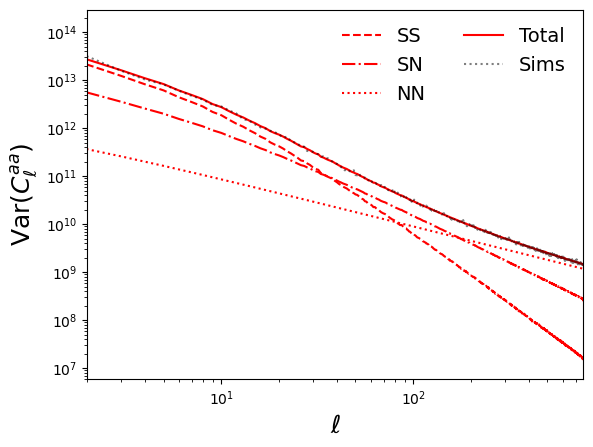

In [9]:
clbar_2d = 0.5*(clbar[:, None] + clbar[None, :])

cov_pcl_ana_ss = 2*clbar_2d**2 * xi_ss
cov_pcl_ana_sn = 2*2*clbar_2d * xi_sn
cov_pcl_ana_nn = 2*xi_nn
cov_pcl_ana = cov_pcl_ana_ss + cov_pcl_ana_sn + cov_pcl_ana_nn

plt.figure()
plt.plot(ls, np.diag(cov_pcl_ana_ss), 'r--', label='SS')
plt.plot(ls, np.diag(cov_pcl_ana_sn), 'r-.', label='SN')
plt.plot(ls, np.diag(cov_pcl_ana_nn), 'r:', label='NN')
plt.plot(ls, np.diag(cov_pcl_ana), 'r-', label='Total')
plt.plot(ls, np.std(pcls, axis=0)**2, 'k:', alpha=0.5, label='Sims')
plt.xlim([2, lmax])
plt.loglog()
plt.xlabel(r'$\ell$', fontsize=18)
plt.ylabel(r'${\rm Var}(C_\ell^{aa})$', fontsize=18)
plt.legend(fontsize=14, frameon=False, ncol=2)